### 1. Introduction to Convolutional Neural Networks (CNNs)
A CNN processes images by passing them through a series of specialized layers.

**Core Layers of a CNN:**
| Layer Type | Function |
| :--- | :--- |
| **Input Layer** | Represents the image as a matrix of pixels. Grayscale images have 1 channel; RGB images have 3 channels. |
| **Convolution Layer** | Slides filters (kernels) over the input image to extract features like edges, textures, and shapes. |
| **Activation (ReLU)** | Applies the Rectified Linear Unit function to introduce non-linearity by replacing all negative pixel values with 0. |
| **Pooling Layer** | Downsamples the image to reduce computation and prevent overfitting while retaining the most important features. |
| **Flatten Layer** | Converts the final 2D/3D feature maps into a 1D vector so it can be fed into a standard neural network. |
| **Fully Connected (Dense)**| Standard linear layers that map the extracted features to the final classification labels (e.g., Cat vs. Dog). |


In [1]:
import tensorflow as tf
from tensorflow.keras import datasets
import matplotlib.pyplot as plt

2026-05-24 15:33:59.768677: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-24 15:33:59.851223: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-24 15:34:01.120784: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Load Data
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

print("Original Dimensions: ")
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Normalize Data
X_train_n = X_train / 255.0
X_test_n = X_test / 255.0

# Reshape for CNN (samples, height, width, channels)
X_train_n_r = X_train_n.reshape(-1, 28, 28, 1)
X_test_n_r = X_test_n.reshape(-1, 28, 28, 1)

print("\nDimensions After Reshaping:")
print(X_train_n_r.shape)
print(y_train.shape)
print(X_test_n_r.shape)
print(y_test.shape)

Original Dimensions: 
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)

Dimensions After Reshaping:
(60000, 28, 28, 1)
(60000,)
(10000, 28, 28, 1)
(10000,)


# Training Simple Model

In [6]:
model = tf.keras.Sequential([

    # Input Layer
    tf.keras.Input(shape=(28, 28, 1)),

    # 1st Convolution + Pooling
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # 2nd Convolution + Pooling
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Flatten
    tf.keras.layers.Flatten(),

    # Fully Connected Layers
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_n_r, y_train, epochs=5, validation_split=0.2)
test_loss, test_acc = model.evaluate(X_test_n_r, y_test)
print("Test Accuracy: ", test_acc)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9491 - loss: 0.1634 - val_accuracy: 0.9782 - val_loss: 0.0684
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9833 - loss: 0.0526 - val_accuracy: 0.9866 - val_loss: 0.0450
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9887 - loss: 0.0351 - val_accuracy: 0.9884 - val_loss: 0.0386
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9910 - loss: 0.0284 - val_accuracy: 0.9871 - val_loss: 0.0436
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9936 - loss: 0.0198 - val_accuracy: 0.9835 - val_loss: 0.0611
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9853 - loss: 0.0466
Test Accuracy:  0.9853000044822693


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


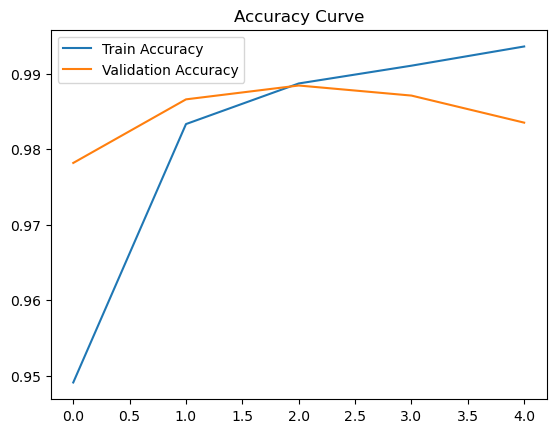

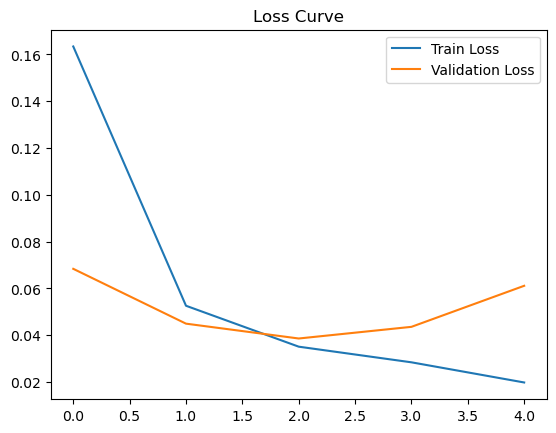

In [8]:
print(history.history.keys())

# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

| Data Split | Where It Comes From | Can the Model Learn/Update Weights From It? | Its Real Purpose |
|------------|---------------------|----------------------------------------------|------------------|
| Training Set (80% of train) | Original training data | Yes | Model learns patterns and updates weights here |
| Validation Set (20% of train) | Original training data | No | Used after each epoch to check overfitting (internal check) |
| Test Set (Separate array) | Original test data | No | Final evaluation after training is complete |

# Training Model with BatchNormalization and Dropout

In [9]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),  # Input: grayscale image (28x28)

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),  # 32 filters to extract basic features (edges, textures)
    tf.keras.layers.BatchNormalization(),  # Stabilizes and speeds up training
    tf.keras.layers.MaxPooling2D((2,2)),  # Reduces spatial size (downsampling)

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),  # Deeper layer learns more complex features
    tf.keras.layers.BatchNormalization(),  # Normalizes activations again for stability
    tf.keras.layers.MaxPooling2D((2,2)),  # Further downsampling

    tf.keras.layers.Flatten(),  # Converts 2D feature maps into 1D vector

    tf.keras.layers.Dense(64, activation='relu'),  # Fully connected layer for learning combinations of features
    tf.keras.layers.Dropout(0.5),  # Randomly drops neurons to reduce overfitting

    tf.keras.layers.Dense(10, activation='softmax')  # Output layer for 10-class classification
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,314 (477.79 KB)

 Trainable params: 122,122 (477.04 KB)

 Non-trainable params: 192 (768.00 B)

In [10]:
model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_n_r, y_train, epochs=5, validation_split=0.2)
test_loss, test_acc = model.evaluate(X_test_n_r, y_test)
print("Test Accuracy: ", test_acc)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8997 - loss: 0.3241 - val_accuracy: 0.9837 - val_loss: 0.0613
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9576 - loss: 0.1453 - val_accuracy: 0.9843 - val_loss: 0.0531
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9692 - loss: 0.1080 - val_accuracy: 0.9819 - val_loss: 0.0611
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9728 - loss: 0.0919 - val_accuracy: 0.9862 - val_loss: 0.0545
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9757 - loss: 0.0771 - val_accuracy: 0.9895 - val_loss: 0.0413
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9889 - loss: 0.0363
Test Accuracy:  0.9889000058174133


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


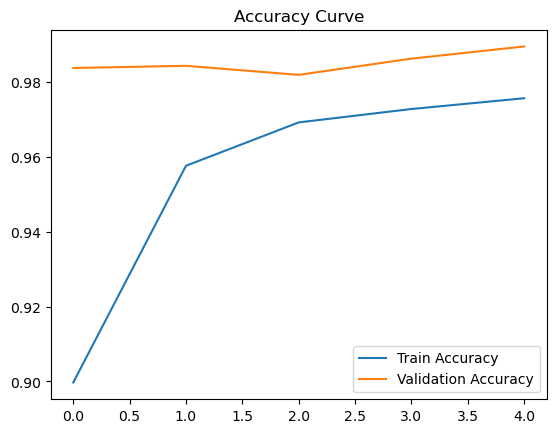

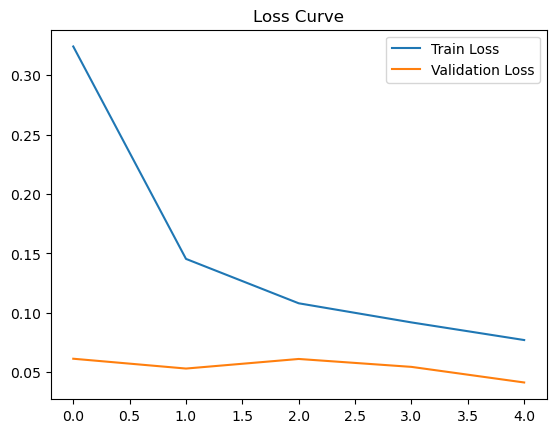

In [11]:
print(history.history.keys())

# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()